In [2]:
import kagglehub
import os
import random
from PIL import Image

In [3]:
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
path = ".."+path+"/New Plant Diseases Dataset(Augmented)"+"/New Plant Diseases Dataset(Augmented)"
train_path = path+"/train"

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


In [4]:
classes = [name for name in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, name))]
print(classes)

['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Strawberry___Leaf_scorch', 'Peach___healthy', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Peach___Bacterial_spot', 'Apple___Cedar_apple_rust', 'Tomato___Target_Spot', 'Pepper,_bell___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___Late_blight', 'Tomato___Tomato_mosaic_virus', 'Strawberry___healthy', 'Apple___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Common_rust_', 'Grape___Esca_(Black_Measles)', 'Raspberry___healthy', 'Tomato___Leaf_Mold', 'Tomato__

In [5]:
classes = [name for name in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, name))]
class_name = random.choice(classes)
class_path = os.path.join(train_path, class_name)
image_name = random.choice(os.listdir(class_path))
image_path = os.path.join(class_path, image_name)

img = Image.open(image_path)

print(class_name)
img.show()

Tomato___Bacterial_spot


In [6]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [7]:
weight, bias = 0.7, 0.3
X = torch.arange(0, 2, 0.02).unsqueeze(dim=1)
y = weight * X + bias
len(X), len(y)
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [8]:
class SampleModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1, requires_grad = True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad = True, dtype=torch.float))
  def forward(self, x: torch.Tensor):
    return (self.weight * x) + self.bias

In [9]:
torch.manual_seed(42)
model_first = SampleModel()

In [10]:
model_first.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
pip install sympy==1.12


In [11]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_first.parameters(), lr=0.00001)
def plot_predictions(X_train, y_train, X_test, y_test, y_preds=None):
  plt.scatter(X_train, y_train, c ="b")
  plt.scatter(X_test, y_test, c = "g")
  if y_preds is not None:
    plt.scatter(X_test, y_preds, c="r")

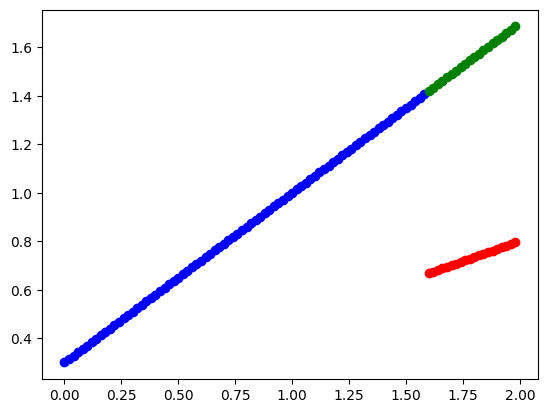

In [12]:
with torch.inference_mode():
  y_preds = model_first(X_test)
plot_predictions(X_train, y_train, X_test, y_test, y_preds)

In [13]:
torch.manual_seed(42)

epochs = 100

for epoch in range(epochs):
  model_first.train()

  y_pred = model_first(X_train)

  loss = loss_fn(y_pred, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_first.eval()
  with torch.inference_mode():
    test_pred = model_first(X_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    print(f"epoch {epoch} | loss {loss} | test loss {test_loss}")

epoch 0 | loss 0.4582051634788513 | test loss 0.8214906454086304
epoch 10 | loss 0.45804286003112793 | test loss 0.8212493062019348
epoch 20 | loss 0.457880437374115 | test loss 0.821008026599884
epoch 30 | loss 0.4577180743217468 | test loss 0.8207665681838989
epoch 40 | loss 0.4575556814670563 | test loss 0.8205251693725586
epoch 50 | loss 0.4573933184146881 | test loss 0.8202838897705078
epoch 60 | loss 0.45723095536231995 | test loss 0.820042610168457
epoch 70 | loss 0.4570685923099518 | test loss 0.8198012113571167
epoch 80 | loss 0.45690616965293884 | test loss 0.8195598721504211
epoch 90 | loss 0.4567438066005707 | test loss 0.8193184733390808


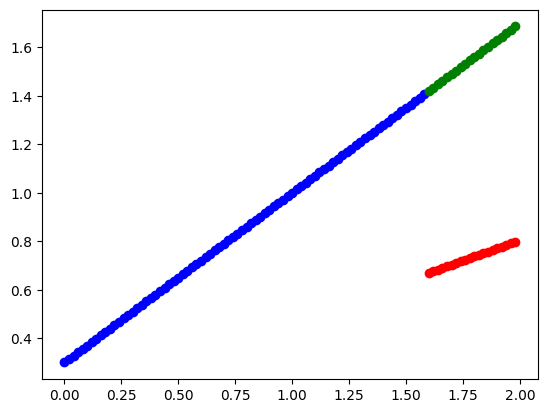

In [14]:
with torch.inference_mode():
  y_preds = model_first(X_test)
plot_predictions(X_train, y_train, X_test, y_test, y_preds)

In [15]:
model_first.state_dict()
len(classes)

38

In [16]:
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

In [17]:
data_transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Using common ImageNet mean and std
])
train_dataset = datasets.ImageFolder(root = train_path, transform=None)
valid_dataset = datasets.ImageFolder(root = path, transform=data_transformer) # Corrected val_path to path
len(train_dataset), len(valid_dataset)

(70295, 87867)

In [18]:
transformed_img = data_transformer(img)
print(transformed_img)

tensor([[[ 0.9474,  0.9474,  0.9303,  ...,  0.8618,  0.7933,  0.6563],
         [ 0.9132,  0.9132,  0.8961,  ...,  0.7933,  0.7419,  0.6392],
         [ 0.8789,  0.8618,  0.8618,  ...,  0.7933,  0.7933,  0.7248],
         ...,
         [ 0.0056, -0.0116,  0.0227,  ...,  0.0227,  0.1426,  0.2111],
         [ 0.1768,  0.1426,  0.1597,  ...,  0.0912,  0.1426,  0.1426],
         [ 0.0912,  0.0741,  0.1426,  ...,  0.0227, -0.0629, -0.1828]],

        [[ 1.0105,  1.0105,  0.9930,  ...,  0.9055,  0.8354,  0.6954],
         [ 0.9755,  0.9755,  0.9580,  ...,  0.8354,  0.7829,  0.6779],
         [ 0.9405,  0.9230,  0.9230,  ...,  0.8354,  0.8354,  0.7654],
         ...,
         [-0.1099, -0.1275, -0.0924,  ..., -0.0574,  0.0651,  0.1352],
         [ 0.0651,  0.0301,  0.0476,  ...,  0.0126,  0.0651,  0.0651],
         [-0.0224, -0.0399,  0.0301,  ..., -0.0574, -0.1450, -0.2675]],

        [[ 1.1759,  1.1759,  1.1585,  ...,  1.1237,  1.0539,  0.9145],
         [ 1.1411,  1.1411,  1.1237,  ...,  1

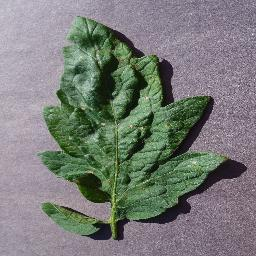

In [ ]:
img


In [19]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle = False, num_workers=2)
len(train_loader), len(valid_loader)

(2197, 2746)

In [19]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def compute_mean_std(dataset, batch_size=64, num_workers=2):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    mean = torch.zeros(3)
    std = torch.zeros(3)
    total_images = 0

    for images, _ in loader:
        B, C, H, W = images.shape
        images = images.view(B, C, -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images += B

    mean /= total_images
    std /= total_images
    return mean, std

train_transform_no_norm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
train_dataset_for_stats = datasets.ImageFolder(root=train_path, transform=train_transform_no_norm)
mean, std = compute_mean_std(train_dataset_for_stats)
print("Mean:", mean)
print("Std:", std)


Mean: tensor([0.4760, 0.5004, 0.4266])
Std: tensor([0.1775, 0.1509, 0.1960])


In [20]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

mean = [0.4760, 0.5004, 0.4266]
std  = [0.1775, 0.1509, 0.1960]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


In [21]:
train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=path, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
len(train_loader), len(val_loader)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


(2197, 2746)

In [22]:
import torch
import torch.nn as nn

class CNNModel(nn.Module):
    def __init__(self, input_shape=(3, 32, 32), num_classes=10):
        super(CNNModel, self).__init__()

        # Convolutional layers
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )


        self.fc_layers = nn.Sequential(
            nn.Linear(128*28*28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = CNNModel(input_shape=(3, 32, 32), num_classes=10)
print(model)


CNNModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=100352, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

epochs = 10
learning_rate = 0.001

class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # (32, 112, 112)

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # (64, 56, 56)

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)    # (128, 28, 28) for 224x224 input
        )

        # dynamically compute flatten size instead of hardcoding
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224)  # same as your resized input
            dummy_out = self.conv_layers(dummy)
            self._to_linear = dummy_out.view(1, -1).shape[1]

        self.fc_layers = nn.Sequential(
            nn.Linear(self._to_linear, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc_layers(x)
        return x


# 🔹 Prepare model
classes = [name for name in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, name))]
model = CNNModel(num_classes=len(classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 🔹 Training Loop
for epoch in range(epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader.dataset)
    train_acc = 100.0 * correct / total

    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader.dataset)
    val_acc = 100.0 * correct / total

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")


Using: cuda
Epoch 1/10 | Train Loss: 1.6022, Acc: 52.17% | Val Loss: 9.7091, Acc: 2.83%


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image

class CNNModel(nn.Module):
    def __init__(self, input_shape=(3, 32, 32), num_classes=10):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNNModel()
model.load_state_dict(torch.load("cnn_weights.pth"))
model.eval()
print("✅ Model weights loaded successfully!")

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


image_path = input("Enter the path of the image: ")
image = Image.open(image_path).convert("RGB")
image = transform(image).unsqueeze(0)


with torch.no_grad():
    y_pred = model(image)
    predicted_class = torch.argmax(y_pred, dim=1).item()

print(f"🎯 Predicted Class: {predicted_class}")


FileNotFoundError: [Errno 2] No such file or directory: 'cnn_weights.pth'

In [23]:

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

model = CNNModel(num_classes=len(train_dataset.classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 15
best_acc = 0.0

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}] | Train Accuracy: {train_acc:.2f}%")

    if train_acc > best_acc:
        best_acc = train_acc
        torch.save(model.state_dict(), "cnn_model_weights.pth")

print(f"✅ Best Model Saved with Accuracy: {best_acc:.2f}%")


Using: cuda


Epoch [1/15] | Train Accuracy: 55.62%


Epoch [2/15] | Train Accuracy: 75.51%


Epoch [3/15] | Train Accuracy: 81.20%


Epoch [4/15] | Train Accuracy: 84.08%


...

Epoch [11/15] | Train Accuracy: 90.94%


Epoch [12/15] | Train Accuracy: 91.65%


Epoch [13/15] | Train Accuracy: 91.63%


Epoch [14/15] | Train Accuracy: 92.19%


Epoch [15/15] | Train Accuracy: 92.43%
✅ Best Model Saved with Accuracy: 92.43%


In [24]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
from google.colab import files
import os

# --- Load model again ---
model = CNNModel(num_classes=len(train_dataset.classes))
model.load_state_dict(torch.load("cnn_model_weights.pth", map_location="cpu"))
model.eval()

# --- Class names ---
class_names = train_dataset.classes

# --- Image transform (same as training normalization) ---
mean = [0.4760, 0.5004, 0.4266]
std = [0.1775, 0.1509, 0.1960]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# --- Ask user to upload image ---
print("📤 Pick an image to upload...")
uploaded = files.upload()

if uploaded:
    img_name = next(iter(uploaded.keys()))
    img_path = f"/content/{img_name}"

    # Load and preprocess
    img = Image.open(img_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0)

    # Predict
    with torch.inference_mode():
        outputs = model(input_tensor)
        probs = F.softmax(outputs, dim=1)
        top1_prob, top1_idx = probs.topk(1, dim=1)

    label = class_names[top1_idx[0][0]]
    score = top1_prob[0][0].item()

    print(f"\n🔍 Top-1 Prediction for: {img_path}")
    print(f"{label:30s} {score:.4f}")

📤 Pick an image to upload...


Saving 0257329a-7b6b-42a5-99db-0dbdf116b89d___RS_HL 5456.JPG to 0257329a-7b6b-42a5-99db-0dbdf116b89d___RS_HL 5456.JPG

🔍 Top-1 Prediction for: /content/0257329a-7b6b-42a5-99db-0dbdf116b89d___RS_HL 5456.JPG
Blueberry___healthy            1.0000


In [25]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [27]:
torch.save(model, '/content/drive/MyDrive/cnn_full_model.pth')
print("✅ Full model (architecture + weights) saved to Drive!")


✅ Full model (architecture + weights) saved to Drive!
